# Temporal Analysis of PM Pollution in Nairobi

This notebook analyzes temporal trends in PM pollution,
including daily and hourly patterns.


## Objectives

- Analyze PM2.5 pollution trends over time
- Identify daily and hourly pollution patterns
- Detect temporal variability in air quality
- Apply data cleaning to remove unrealistic sensor values


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading Prepared Temporal Dataset

The dataset used in this analysis contains PM2.5 (P2) measurements with
timestamps. The data has already been filtered for particulate matter
in the data preparation stage.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/air_quality/Outputs/clean_temporal_pm.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], format='ISO8601')

/tmp/ipython-input-3116324713.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/air_quality/Outputs/clean_temporal_pm.csv")


## Data Quality Check

Initial inspection revealed extremely high PM2.5 values that distort
temporal visualizations. Such values are likely caused by sensor
malfunctions or data recording errors.


In [27]:
df["value"].describe()

,value
count,3995407.0
unique,22904.0
top,10.0
freq,33364.0


## Outlier Removal

PM2.5 values above 500 µg/m³ are considered unrealistic for ambient air
quality conditions. These values are removed to ensure meaningful
temporal analysis.


In [28]:
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df_clean = df[df["value"] <= 500]
df_clean["value"].describe()

,value
count,3.991299e+06
mean,1.132692e+01
std,2.254793e+01
min,0.000000e+00
25%,4.570000e+00
50%,7.730000e+00
75%,1.300000e+01
max,5.000000e+02


## Daily Average PM2.5 Pollution

Daily averages are computed to smooth short-term fluctuations and
highlight longer-term pollution trends.


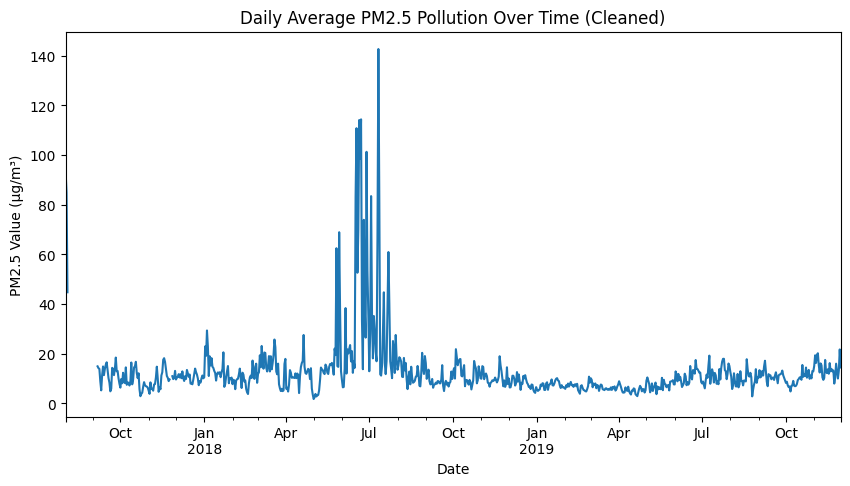

In [29]:
daily_avg = (df_clean.set_index("timestamp")["value"].resample("D").mean())

daily_avg.plot(figsize=(10,5))
plt.title("Daily Average PM2.5 Pollution Over Time (Cleaned)")
plt.xlabel("Date")
plt.ylabel("PM2.5 Value (µg/m³)")
plt.show()


## Hourly PM2.5 Pollution Patterns

Hourly averages are computed to identify intra-day pollution patterns,
which may be influenced by traffic activity and human behavior.


/tmp/ipython-input-9852042.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["hour"] = df_clean["timestamp"].dt.hour


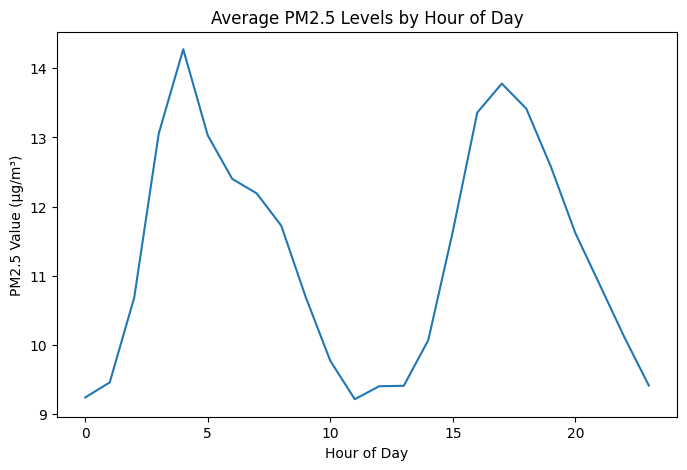

In [30]:
df_clean["hour"] = df_clean["timestamp"].dt.hour
hourly_avg = df_clean.groupby("hour")["value"].mean()

hourly_avg.plot(figsize=(8,5))
plt.title("Average PM2.5 Levels by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5 Value (µg/m³)")
plt.show()

